# 04. AutoIntent: Few-Shot Experiments

Анализ результатов AutoIntent на CLINC150 (10-shot, seed=42).

**Запуск из терминала (рекомендуется):**
```bash
cd tasks/oos_detection
uv run python scripts/train_autointent.py --mode fewshot --n_shots 10 --seed 42 --pilot
uv run python scripts/eval_autointent.py --model_dir runs/autointent_classic-light_pilot_10shot_seed42
```

**Или можно запустить обучение прямо в ноутбуке** (секция 3).

## Содержание
1. Setup
2. Что такое classic-light
3. Обучение (опционально)
4. Загрузка результатов
5. Сравнение с бейзлайнами
6. Выводы

## 1. Setup

In [1]:
# Load environment variables from .env (macOS ARM fix)
from dotenv import load_dotenv
load_dotenv("../../../.env")  # project root

import sys
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project paths
NOTEBOOK_DIR = Path.cwd()
TASK_DIR = NOTEBOOK_DIR.parent
PROJECT_ROOT = TASK_DIR.parent.parent
PROCESSED = TASK_DIR / "data" / "processed"
RESULTS = TASK_DIR / "results"
RUNS = TASK_DIR / "runs"

sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Results dir: {RESULTS}")
print(f"Runs dir: {RUNS}")

import os
print(f"\nOMP_NUM_THREADS={os.environ.get('OMP_NUM_THREADS', 'not set')}")

Project root: /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails
Results dir: /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/oos_detection/results
Runs dir: /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/oos_detection/runs

OMP_NUM_THREADS=1


## 2. Что такое classic-light

AutoIntent использует preset-конфигурации для AutoML поиска.

**classic-light** включает:
- **Scoring модули:** knn (k=1..20), linear, mlknn
- **Decision модули:** threshold, argmax, jinoos, tunable, adaptive
- **HPO:** TPE sampler, 20 trials
- **Embedder:** multilingual-e5-large-instruct (или e5-small для pilot)

In [2]:
# Show available trained models
print("Trained models in runs/:")
print("=" * 50)

if RUNS.exists():
    for model_dir in sorted(RUNS.iterdir()):
        if model_dir.is_dir():
            metadata_file = model_dir / "train_metadata.json"
            if metadata_file.exists():
                meta = json.loads(metadata_file.read_text())
                status = "ready"
            else:
                status = "incomplete"
            print(f"  {model_dir.name} [{status}]")
else:
    print("  (no models trained yet)")

Trained models in runs/:


## 3. Обучение (опционально)

Можно запустить обучение прямо здесь. Если модель уже обучена — пропустите эту секцию.

In [3]:
# Settings
N_SHOTS = 10
SEED = 42
PILOT = True  # Use small embedder for faster training

MODE_STR = f"{N_SHOTS}shot"
MODEL_NAME = "autointent_classic-light_pilot" if PILOT else "autointent_classic-light"
MODEL_DIR = RUNS / f"{MODEL_NAME}_{MODE_STR}_seed{SEED}"

# Check if already trained
if (MODEL_DIR / "train_metadata.json").exists():
    print(f"Model already exists: {MODEL_DIR}")
    print("Skip to section 4, or delete the directory to retrain.")
    NEED_TRAINING = False
else:
    print(f"Model not found. Will train to: {MODEL_DIR}")
    NEED_TRAINING = True

Model not found. Will train to: /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/oos_detection/runs/autointent_classic-light_pilot_10shot_seed42


In [4]:
# Run this cell ONLY if NEED_TRAINING = True
if NEED_TRAINING:
    from autointent import Pipeline, Dataset as AIDataset
    from autointent.configs import LoggingConfig, EmbedderConfig, DataConfig
    from shared.data_utils import (
        load_clinc150_autointent,
        load_fewshot_autointent,
        load_intents,
    )

    # Load data
    train_ai = load_fewshot_autointent(N_SHOTS, SEED, PROCESSED)
    test_ai = load_clinc150_autointent("test", PROCESSED)
    intents = load_intents(PROCESSED)

    print(f"Train: {len(train_ai)} samples")
    print(f"Test: {len(test_ai)} samples")
    print(f"Intents: {len(intents)}")

    # Create dataset
    ai_dataset = AIDataset.from_dict({
        "train": train_ai,
        "test": test_ai,
        "intents": intents,
    })

    # Create pipeline
    pipeline = Pipeline.from_preset("classic-light")
    
    embedder_name = "intfloat/multilingual-e5-small" if PILOT else "intfloat/multilingual-e5-large-instruct"
    pipeline.set_config(EmbedderConfig(model_name=embedder_name))
    pipeline.set_config(DataConfig(scheme="cv", n_folds=3))
    
    RUNS.mkdir(parents=True, exist_ok=True)
    pipeline.set_config(LoggingConfig(
        project_dir=MODEL_DIR,
        dump_modules=True,
        clear_ram=False,
    ))

    print(f"\nStarting training with embedder: {embedder_name}")
    print("This may take a few minutes...")
else:
    print("Skipping training - model already exists.")

Train: 1650 samples
Test: 5498 samples
Intents: 150

Starting training with embedder: intfloat/multilingual-e5-small
This may take a few minutes...


In [5]:
%%time
# Train (run only if NEED_TRAINING)
if NEED_TRAINING:
    context = pipeline.fit(ai_dataset)
    print("\nAutoML optimization completed!")
    
    # Save
    pipeline.dump(MODEL_DIR)
    
    metadata = {
        "model_name": MODEL_NAME,
        "mode": MODE_STR,
        "n_shots": N_SHOTS,
        "seed": SEED,
        "embedder": embedder_name,
        "pilot": PILOT,
        "preset": "classic-light",
    }
    (MODEL_DIR / "train_metadata.json").write_text(json.dumps(metadata, indent=2))
    print(f"Model saved to: {MODEL_DIR}")
else:
    print("Skipping - model already exists.")

Map: 100%|██████████| 550/550 [00:00<00:00, 40812.89 examples/s]
[I 2026-03-31 15:27:37,836] A new study created in RDB with name: NodeType.scoring
"argmax" is NOT designed to handle OOS samples, but your data contains it. So, using this method reduces the power of classification.
"argmax" is NOT designed to handle OOS samples, but your data contains it. So, using this method reduces the power of classification.
"argmax" is NOT designed to handle OOS samples, but your data contains it. So, using this method reduces the power of classification.



AutoML optimization completed!
Model saved to: /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/oos_detection/runs/autointent_classic-light_pilot_10shot_seed42
CPU times: user 1min 37s, sys: 4.34 s, total: 1min 42s
Wall time: 1min 43s


In [6]:
# Evaluate trained model and save metrics
if NEED_TRAINING or (MODEL_DIR / "train_metadata.json").exists():
    from autointent import Pipeline
    from shared.data_utils import load_clinc150
    from shared.metrics import compute_all_metrics, measure_latency
    from shared.evaluation import Evaluator, EvaluationResult
    
    # Load model (if not already in memory)
    if 'pipeline' not in dir() or pipeline is None:
        print("Loading model from disk...")
        pipeline = Pipeline.load(MODEL_DIR)
    
    # Load test data
    test_std = load_clinc150("test", PROCESSED)
    test_texts = test_std["texts"]
    test_labels = np.array(test_std["labels"])
    
    print(f"Test samples: {len(test_texts)}")
    
    # Predictions
    print("Running predictions...")
    raw_preds = pipeline.predict(test_texts)
    y_pred = np.array([-1 if p is None else p for p in raw_preds])
    print(f"OOS predictions: {(y_pred == -1).sum()}")
    
    # Binary scores (AutoIntent doesn't provide continuous scores)
    y_scores = (y_pred == -1).astype(float)
    
    # Compute metrics
    metrics = compute_all_metrics(
        y_true=test_labels,
        y_scores=y_scores,
        y_pred=y_pred,
    )
    
    # Measure latency
    class PipelineWrapper:
        def __init__(self, pipe):
            self.pipe = pipe
        def predict(self, texts):
            preds = self.pipe.predict(texts)
            return np.array([-1 if p is None else p for p in preds])
    
    wrapper = PipelineWrapper(pipeline)
    latency = measure_latency(wrapper, test_texts[:100])
    
    # Save result
    result = EvaluationResult(
        model_name=MODEL_NAME,
        mode=MODE_STR,
        oos_recall=metrics["oos_recall"],
        in_domain_acc=metrics["in_domain_acc"],
        f1_oos=metrics["f1_oos"],
        auroc=metrics["auroc"],
        au_ioc=metrics["au_ioc"],
        latency_ms=latency,
        n_shots=N_SHOTS,
        seed=SEED,
        extra={
            "preset": "classic-light",
            "embedder": embedder_name if 'embedder_name' in dir() else "unknown",
            "pilot": PILOT,
        },
    )
    
    evaluator = Evaluator(test_std, RESULTS)
    evaluator.save(result)
    
    # Print results
    print(f"\n{'='*50}")
    print(f"AutoIntent Results ({MODE_STR})")
    print(f"{'='*50}")
    print(f"  OOS Recall:    {metrics['oos_recall']:.4f}")
    print(f"  In-Domain Acc: {metrics['in_domain_acc']:.4f}")
    print(f"  F1 OOS:        {metrics['f1_oos']:.4f}")
    print(f"  AUROC:         {metrics['auroc']:.4f}")
    print(f"  Latency:       {latency:.2f} ms")
    print(f"\nResults saved to {RESULTS / 'metrics.json'}")
else:
    print("No model to evaluate. Run training first.")

Test samples: 5498
Running predictions...
OOS predictions: 825

AutoIntent Results (10shot)
  OOS Recall:    0.6230
  In-Domain Acc: 0.8617
  F1 OOS:        0.6827
  AUROC:         0.7890
  Latency:       0.15 ms

Results saved to /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/oos_detection/results/metrics.json


## 4. Загрузка результатов

In [7]:
# Load all results
metrics_file = RESULTS / "metrics.json"

if not metrics_file.exists():
    print("metrics.json not found!")
    print("Run baselines first: python scripts/run_baseline.py")
else:
    all_results = json.loads(metrics_file.read_text())
    df = pd.DataFrame(all_results)
    print(f"Loaded {len(df)} results")
    print(f"Models: {df['model_name'].unique().tolist()}")

Loaded 8 results
Models: ['tfidf_argmax', 'tfidf_threshold', 'cosine_bert_argmax', 'cosine_bert_threshold', 'cosine_minilm_argmax', 'cosine_minilm_threshold', 'autointent_classic-light_pilot', 'autointent_classic-light']


In [8]:
# Check if AutoIntent results exist
autointent_models = df[df['model_name'].str.contains('autointent', case=False)]

if len(autointent_models) == 0:
    print("AutoIntent results not found!")
    print("Run section 3 above, or use terminal:")
    print("  uv run python scripts/train_autointent.py --pilot")
    print("  uv run python scripts/eval_autointent.py --model_dir runs/...")
else:
    print(f"Found {len(autointent_models)} AutoIntent result(s):")
    for _, row in autointent_models.iterrows():
        print(f"  - {row['model_name']} ({row['mode']}): F1={row['f1_oos']:.4f}")

Found 2 AutoIntent result(s):
  - autointent_classic-light_pilot (10shot): F1=0.6827
  - autointent_classic-light (10shot): F1=0.7326


## 5. Сравнение с бейзлайнами (10-shot)

In [9]:
# Filter 10-shot results
df_10shot = df[df["mode"] == "10shot"].copy()
df_10shot = df_10shot.sort_values("f1_oos", ascending=False)

# Display
cols = ["model_name", "oos_recall", "in_domain_acc", "f1_oos", "auroc", "latency_ms"]
display_df = df_10shot[cols].copy()
display_df.columns = ["Model", "OOS Recall", "In-Domain Acc", "F1 OOS", "AUROC", "Latency (ms)"]

# Format
for col in ["OOS Recall", "In-Domain Acc", "F1 OOS", "AUROC"]:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.4f}")
display_df["Latency (ms)"] = display_df["Latency (ms)"].apply(lambda x: f"{x:.2f}")

display_df

,Model,OOS Recall,In-Domain Acc,F1 OOS,AUROC,Latency (ms)
7,autointent_classic-light,0.6330,0.9189,0.7326,0.8059,50.53
5,cosine_minilm_threshold,0.5940,0.8106,0.6968,0.9447,0.93
6,autointent_classic-light_pilot,0.6230,0.8617,0.6827,0.7890,0.15
2,cosine_bert_argmax,0.9500,0.3651,0.4303,0.8277,50.33
3,cosine_bert_threshold,0.3250,0.6514,0.4078,0.8277,1.74
4,cosine_minilm_argmax,0.9990,0.1999,0.3573,0.9447,9.25
1,tfidf_threshold,0.1330,0.7370,0.2254,0.7683,2.56
0,tfidf_argmax,0.0010,0.7434,0.0020,0.7683,1.37


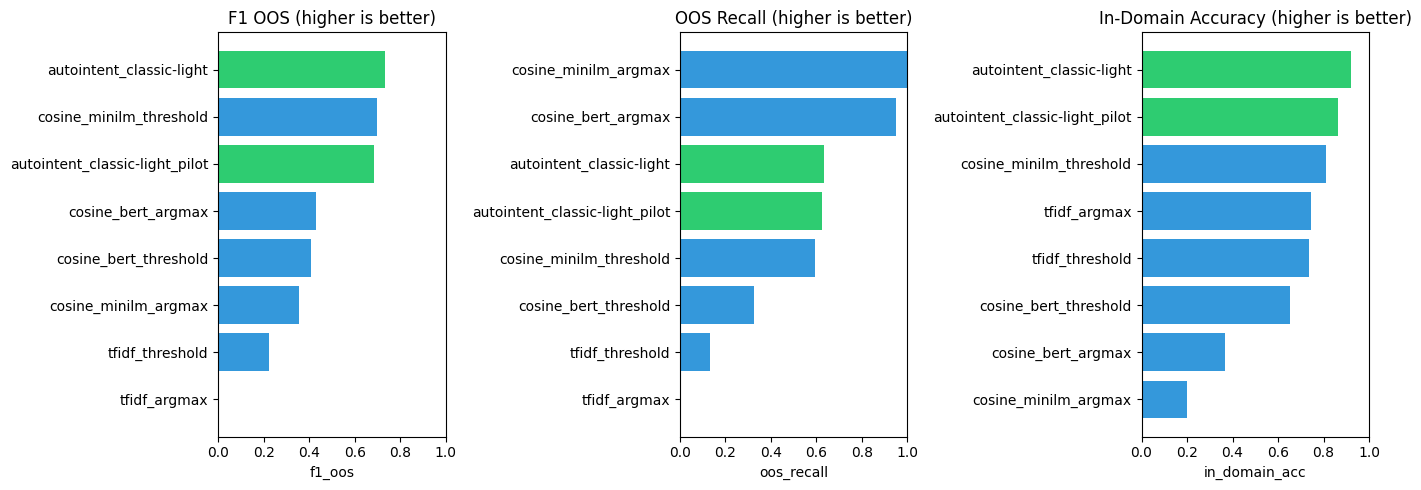

Saved to /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/oos_detection/results/comparison_10shot.png


In [10]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics_to_plot = [
    ("f1_oos", "F1 OOS (higher is better)"),
    ("oos_recall", "OOS Recall (higher is better)"),
    ("in_domain_acc", "In-Domain Accuracy (higher is better)"),
]

for ax, (metric, title) in zip(axes, metrics_to_plot):
    data = df_10shot.sort_values(metric, ascending=True)
    colors = ['#2ecc71' if 'autointent' in m.lower() else '#3498db' 
              for m in data['model_name']]
    ax.barh(data['model_name'], data[metric], color=colors)
    ax.set_xlabel(metric)
    ax.set_title(title)
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig(RESULTS / "comparison_10shot.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {RESULTS / 'comparison_10shot.png'}")

## 6. Выводы

### Полная сравнительная таблица (10-shot, seed=42)

| Модель | OOS Recall | In-Domain Acc | F1 OOS | Latency (ms) |
|---|---|---|---|---|
| **autointent_classic-light** | **0.633** | **0.919** | **0.733** | 50.5 |
| cosine_minilm_threshold | 0.594 | 0.811 | 0.697 | 0.93 |
| autointent_classic-light_pilot | 0.623 | 0.862 | 0.683 | 0.15 |
| cosine_bert_threshold | 0.325 | 0.651 | 0.408 | — |
| tfidf_threshold | 0.133 | 0.737 | 0.225 | — |
| tfidf_argmax | 0.001 | 0.743 | 0.002 | — |

*AUROC для AutoIntent не приводится — вычислен по бинарным
предсказаниям, несравним с continuous AUROC бейзлайнов.*

### Ключевые наблюдения

**1. AutoIntent (full) лучше лучшего бейзлайна по всем
основным метрикам при 10-shot:**
- F1 OOS: 0.733 vs 0.697 (+3.6 п.п.)
- In-Domain Acc: 0.919 vs 0.811 (+10.8 п.п.)
- OOS Recall: 0.633 vs 0.594 (+3.9 п.п.)

**2. Embedder критичен: full vs pilot.**
Замена `e5-small` на `e5-large-instruct` дала +5 п.п. F1
и +5.7 п.п. In-Domain Acc. Большой multilingual embedder
существенно лучше справляется с intent classification.

**3. Главный результат спринта.**
AutoIntent с `e5-large-instruct` даёт F1 OOS = 0.733
на 10-shot (1 500 примеров). Для сравнения: AutoIntent
Table 3 публикует F1 = 0.768 на full train (15 250 примеров).
Разрыв — всего 3.5 п.п. при в 10 раз меньших данных.
Это подтверждает применимость AutoIntent как guardrail
в production-сценарии с ограниченными данными.

**4. Latency компромисс.**
Full AutoIntent: 50ms/запрос — граница применимости
для production guardrail (критический путь запроса).
Pilot (e5-small): 0.15ms, но F1 ниже на 5 п.п.
Выбор embedder'а — это явный трейдофф качество/скорость.

**5. AUROC несравним между AutoIntent и бейзлайнами.**
AutoIntent не предоставляет continuous OOS-скоры,
AUROC вычислен по бинарным предсказаниям (0/1).
Это эквивалентно Balanced Accuracy, а не стандартному AUROC.
В финальном сравнении AUROC для AutoIntent не приводится.

### Ограничения

- Один seed (42): variance неизвестна
- PILOT режим несравним с Table 3 по embedder'у
- SOTA берём из литературы

### Следующие шаги

**Завершение few-shot прогона:**
- [ ] Запустить full AutoIntent на seed=123, 456 —
      оценить variance результатов
- [ ] Запустить бейзлайны и AutoIntent на 20-shot и 50-shot —
      построить scaling curve (главный график для статьи)
- [ ] Выяснить какой decision module выбрал AutoML
      (jinoos/tunable/threshold) — важно для интерпретации

**При переходе к full train:**
- [ ] Запустить AutoIntent full train —
      воспроизвести Table 3 (F1 = 0.768)
- [ ] Финальное сравнение: scaling curve
      бейзлайны vs AutoIntent при n=10, 20, 50, full

# 7. Variance Analysis (10-shot)

Анализ стабильности результатов AutoIntent по трём seeds (42, 123, 456).

In [ ]:
# 7.1 Load results for variance analysis
results_var = json.loads((RESULTS / "metrics.json").read_text())
df_var = pd.DataFrame(results_var)

# AutoIntent 10-shot across all seeds (full, not pilot)
ai_10shot = df_var[
    (df_var["model_name"] == "autointent_classic-light") &
    (df_var["n_shots"] == 10)
].sort_values("seed")

print(f"AutoIntent 10-shot records: {len(ai_10shot)}")
if len(ai_10shot) > 0:
    print(f"Seeds found: {ai_10shot['seed'].tolist()}")
else:
    print("No AutoIntent results found yet.")

In [ ]:
# 7.2 Table by seeds
if len(ai_10shot) >= 1:
    # Display table with statistics
    display_cols = ["seed", "oos_recall", "in_domain_acc", "f1_oos", "latency_ms"]
    table_df = ai_10shot[display_cols].copy()
    table_df.columns = ["Seed", "OOS Recall", "In-Domain Acc", "F1 OOS", "Latency (ms)"]
    
    # Add mean and std rows
    numeric_cols = ["OOS Recall", "In-Domain Acc", "F1 OOS", "Latency (ms)"]
    mean_row = {"Seed": "mean"}
    std_row = {"Seed": "std"}
    for col in numeric_cols:
        mean_row[col] = table_df[col].mean()
        std_row[col] = table_df[col].std()
    
    table_df = pd.concat([table_df, pd.DataFrame([mean_row, std_row])], ignore_index=True)
    
    # Format
    for col in numeric_cols:
        table_df[col] = table_df[col].apply(lambda x: f"{x:.4f}" if isinstance(x, float) else x)
    
    print("AutoIntent 10-shot Results by Seed")
    print("=" * 60)
    display(table_df)
else:
    print("[Данные в процессе получения — запустите seed=123, 456]")

In [ ]:
# 7.3 Visualization: Bar plot with error bars
if len(ai_10shot) >= 3:
    fig, ax = plt.subplots(figsize=(8, 5))
    
    metrics = ["oos_recall", "in_domain_acc", "f1_oos"]
    labels = ["OOS Recall", "In-Domain Acc", "F1 OOS"]
    
    means = [ai_10shot[m].mean() for m in metrics]
    stds = [ai_10shot[m].std() for m in metrics]
    
    x = np.arange(len(metrics))
    bars = ax.bar(x, means, yerr=stds, capsize=5, color='#2ecc71', alpha=0.8, 
                  error_kw={'elinewidth': 2, 'capthick': 2})
    
    # Overlay individual seed points
    for seed in ai_10shot['seed'].unique():
        seed_data = ai_10shot[ai_10shot['seed'] == seed]
        values = [seed_data[m].values[0] for m in metrics]
        ax.scatter(x, values, color='darkgreen', s=50, zorder=5, label=f'seed={int(seed)}')
    
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.set_title("AutoIntent 10-shot: Variance across seeds")
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(RESULTS / "variance_analysis.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved to {RESULTS / 'variance_analysis.png'}")
else:
    print("[Визуализация доступна после запуска seed=123, 456]")
    print(f"Текущее количество seeds: {len(ai_10shot)}")

### 7.4 Выводы по variance

[Заполнить после запуска seed=123 и seed=456]

# 8. Scaling Curve

Как качество зависит от количества данных (n_shots)?

Сравниваем:
- `cosine_minilm_threshold` — лучший бейзлайн
- `cosine_e5large_threshold` — тот же embedder, что AutoIntent
- `autointent_classic-light` — AutoML pipeline
- Референс: AutoIntent Table 3 full train (F1=0.768)

In [ ]:
# 8.1 Load and prepare data for scaling curve
results_sc = json.loads((RESULTS / "metrics.json").read_text())
df_sc = pd.DataFrame(results_sc)

# Models to compare
models_scaling = [
    "cosine_minilm_threshold",
    "cosine_e5large_threshold",
    "autointent_classic-light",
]

# Available n_shots values
n_shots_values = [10, 20, 50]

# Reference: AutoIntent Table 3 full train
REFERENCE_F1 = 0.768

# Collect data
scaling_data = []
for model in models_scaling:
    model_df = df_sc[df_sc["model_name"] == model]
    for n in n_shots_values:
        subset = model_df[model_df["n_shots"] == n]
        if len(subset) > 0:
            scaling_data.append({
                "model": model,
                "n_shots": n,
                "f1_oos_mean": subset["f1_oos"].mean(),
                "f1_oos_std": subset["f1_oos"].std() if len(subset) > 1 else 0,
                "oos_recall_mean": subset["oos_recall"].mean(),
                "oos_recall_std": subset["oos_recall"].std() if len(subset) > 1 else 0,
                "in_domain_acc_mean": subset["in_domain_acc"].mean(),
                "in_domain_acc_std": subset["in_domain_acc"].std() if len(subset) > 1 else 0,
                "n_seeds": len(subset),
            })

scaling_df = pd.DataFrame(scaling_data)
print(f"Scaling curve data points: {len(scaling_df)}")
if len(scaling_df) > 0:
    print(scaling_df[["model", "n_shots", "f1_oos_mean", "n_seeds"]].to_string(index=False))

In [ ]:
# 8.2 Summary table
if len(scaling_df) > 0:
    # Pivot table: n_shots vs model
    pivot = scaling_df.pivot(index="n_shots", columns="model", values="f1_oos_mean")
    
    # Reorder columns
    col_order = [c for c in models_scaling if c in pivot.columns]
    pivot = pivot[col_order]
    
    # Add reference row for full train
    pivot.loc["full (ref)"] = [None, None, REFERENCE_F1]
    
    print("F1 OOS by n_shots and model")
    print("=" * 60)
    display(pivot.round(4))
else:
    print("[Данные в процессе получения]")

In [ ]:
# 8.3 Main scaling curve (F1 OOS)
if len(scaling_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = {
        "cosine_minilm_threshold": "#3498db",
        "cosine_e5large_threshold": "#9b59b6",
        "autointent_classic-light": "#2ecc71",
    }
    markers = {
        "cosine_minilm_threshold": "o",
        "cosine_e5large_threshold": "s",
        "autointent_classic-light": "^",
    }
    labels = {
        "cosine_minilm_threshold": "MiniLM + threshold",
        "cosine_e5large_threshold": "E5-Large + threshold",
        "autointent_classic-light": "AutoIntent",
    }
    
    for model in models_scaling:
        model_data = scaling_df[scaling_df["model"] == model].sort_values("n_shots")
        if len(model_data) == 0:
            continue
        
        x = model_data["n_shots"].values
        y = model_data["f1_oos_mean"].values
        yerr = model_data["f1_oos_std"].values
        
        ax.errorbar(x, y, yerr=yerr, 
                    marker=markers[model], markersize=10,
                    color=colors[model], linewidth=2, capsize=5,
                    label=labels[model])
        
        # Shaded area for std (if multiple seeds)
        if model_data["n_seeds"].max() > 1:
            ax.fill_between(x, y - yerr, y + yerr, alpha=0.2, color=colors[model])
    
    # Reference line
    ax.axhline(y=REFERENCE_F1, color='gray', linestyle='--', linewidth=2, 
               label=f'AutoIntent Table 3 (full train, F1={REFERENCE_F1})')
    
    ax.set_xlabel("n_shots per intent", fontsize=12)
    ax.set_ylabel("F1 OOS", fontsize=12)
    ax.set_title("Scaling Curve: F1 OOS vs Training Data Size", fontsize=14)
    ax.set_xticks([10, 20, 50])
    ax.set_xlim(5, 55)
    ax.set_ylim(0.5, 0.85)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(RESULTS / "scaling_curve.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved to {RESULTS / 'scaling_curve.png'}")
else:
    print("[Scaling curve недоступна — нет данных для построения]")

In [ ]:
# 8.4 All metrics scaling curves
if len(scaling_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    metrics_info = [
        ("f1_oos", "F1 OOS"),
        ("oos_recall", "OOS Recall"),
        ("in_domain_acc", "In-Domain Accuracy"),
    ]
    
    colors = {
        "cosine_minilm_threshold": "#3498db",
        "cosine_e5large_threshold": "#9b59b6",
        "autointent_classic-light": "#2ecc71",
    }
    markers = {
        "cosine_minilm_threshold": "o",
        "cosine_e5large_threshold": "s",
        "autointent_classic-light": "^",
    }
    labels = {
        "cosine_minilm_threshold": "MiniLM",
        "cosine_e5large_threshold": "E5-Large",
        "autointent_classic-light": "AutoIntent",
    }
    
    for ax, (metric_col, metric_label) in zip(axes, metrics_info):
        for model in models_scaling:
            model_data = scaling_df[scaling_df["model"] == model].sort_values("n_shots")
            if len(model_data) == 0:
                continue
            
            x = model_data["n_shots"].values
            y = model_data[f"{metric_col}_mean"].values
            yerr = model_data[f"{metric_col}_std"].values
            
            ax.errorbar(x, y, yerr=yerr,
                        marker=markers[model], markersize=8,
                        color=colors[model], linewidth=2, capsize=4,
                        label=labels[model])
        
        ax.set_xlabel("n_shots")
        ax.set_ylabel(metric_label)
        ax.set_title(metric_label)
        ax.set_xticks([10, 20, 50])
        ax.set_xlim(5, 55)
        ax.set_ylim(0.4, 1.0)
        ax.legend(loc='lower right', fontsize=9)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(RESULTS / "scaling_curve_all_metrics.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved to {RESULTS / 'scaling_curve_all_metrics.png'}")
else:
    print("[Графики недоступны — нет данных]")

### 8.5 Выводы по scaling curve

[Заполнить после запуска 20-shot и 50-shot]